# Analysis of Customer Behavior

**Objective:** Segment e-commerce customers by purchase behavior (RFM analysis), predict churn, estimate customer lifetime value, and deliver insights.

**Dataset:** Online Retail II UCI (UK e-commerce, 2009-2011, ~1M transactions)

**Phases:**
1. Data pipeline & validation
2. Exploratory data analysis + cohort retention
3. RFM scoring + K-Means segmentation
4. Churn prediction & LTV modeling (XGBoost)
5. Statistical hypothesis testing & effect sizes
6. Segment profiles & business recommendations

---

## Setup & Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import scipy.stats as stats

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, roc_curve, classification_report,
                              mean_absolute_error, r2_score, silhouette_score,
                              davies_bouldin_score)
import xgboost as xgb

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print('All libraries imported successfully')

All libraries imported successfully


---
# PHASE 1: DATA PIPELINE & VALIDATION

## 1.1 Load Data

In [2]:
df = pd.read_csv('../data/online_retail_II.csv')
print(f'Raw data shape: {df.shape}')
print(f'\nColumn dtypes:')
print(df.dtypes)
df.head()

Raw data shape: (1067371, 8)

Column dtypes:
Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 1.2 Data Quality Assessment

In [3]:
print('Missing values:')
print(df.isnull().sum())
print(f'\nDuplicate rows: {df.duplicated().sum()}')
df.describe()

Missing values:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Duplicate rows: 34335


,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


## 1.3 Data Cleaning & Feature Engineering

In [4]:
df_clean = df.copy()

df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

df_clean = df_clean.dropna(subset=['Customer ID'])
df_clean['Customer ID'] = df_clean['Customer ID'].astype(int)
print(f'After removing missing CustomerID: {df_clean.shape[0]:,} rows')

df_clean = df_clean[~df_clean['Invoice'].astype(str).str.startswith('C')]
print(f'After removing cancellations: {df_clean.shape[0]:,} rows')

df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]
print(f'After removing invalid records: {df_clean.shape[0]:,} rows')

df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['Price']
df_clean['Year'] = df_clean['InvoiceDate'].dt.year
df_clean['Month'] = df_clean['InvoiceDate'].dt.month
df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.dayofweek
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour

print(f'\nDate range: {df_clean["InvoiceDate"].min().date()} to {df_clean["InvoiceDate"].max().date()}')
print(f'Unique customers: {df_clean["Customer ID"].nunique():,}')
print(f'Unique products:  {df_clean["StockCode"].nunique():,}')
print(f'Unique countries: {df_clean["Country"].nunique():,}')

After removing missing CustomerID: 824,364 rows
After removing cancellations: 805,620 rows
After removing invalid records: 805,549 rows

Date range: 2009-12-01 to 2011-12-09
Unique customers: 5,878
Unique products:  4,631
Unique countries: 41


## 1.4 Outlier Detection

In [5]:
Q1_qty = df_clean['Quantity'].quantile(0.25)
Q3_qty = df_clean['Quantity'].quantile(0.75)
IQR_qty = Q3_qty - Q1_qty
Q1_price = df_clean['TotalPrice'].quantile(0.25)
Q3_price = df_clean['TotalPrice'].quantile(0.75)
IQR_price = Q3_price - Q1_price
outliers_qty = (df_clean['Quantity'] < Q1_qty - 1.5*IQR_qty) | (df_clean['Quantity'] > Q3_qty + 1.5*IQR_qty)
outliers_price = (df_clean['TotalPrice'] < Q1_price - 1.5*IQR_price) | (df_clean['TotalPrice'] > Q3_price + 1.5*IQR_price)
df_clean['is_outlier'] = outliers_qty | outliers_price
pct = df_clean['is_outlier'].mean() * 100
print(f'Outliers detected: {df_clean["is_outlier"].sum():,} ({pct:.2f}%)')
print('Flagged but retained — these are real extreme transactions')
print(f'\nData quality score: {100 - pct:.1f}% clean records')

Outliers detected: 83,809 (10.40%)
Flagged but retained — these are real extreme transactions

Data quality score: 89.6% clean records


---
# PHASE 2: EXPLORATORY DATA ANALYSIS + COHORT ANALYSIS

## 2.1 Revenue Trends

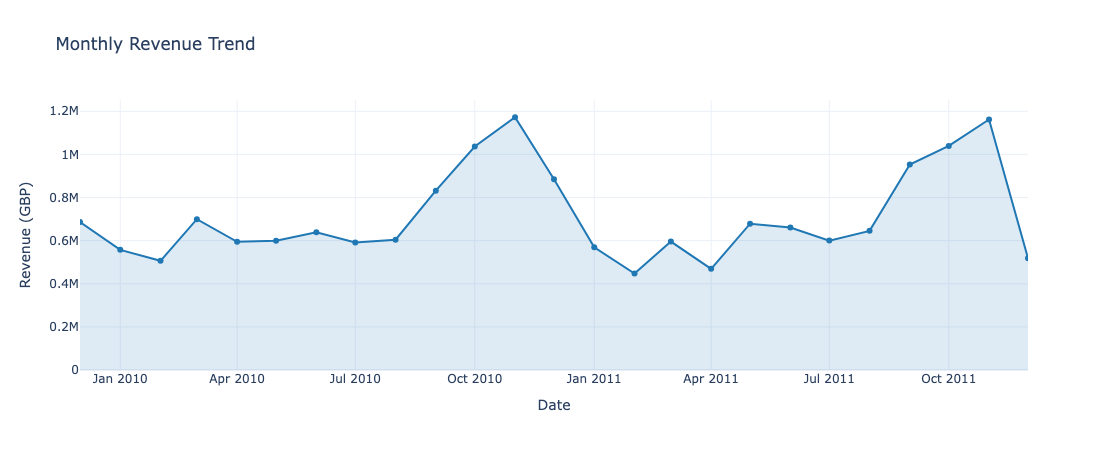

Total revenue:          GBP 17,743,429
Average monthly:        GBP 709,737
Peak month: November 2010 (GBP 1,172,336)


In [6]:
monthly = df_clean.groupby(df_clean['InvoiceDate'].dt.to_period('M'))['TotalPrice'].sum()
monthly.index = monthly.index.to_timestamp()

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=monthly.index, y=monthly.values,
    mode='lines+markers',
    line=dict(color='#1f77b4', width=2),
    fill='tozeroy', fillcolor='rgba(31,119,180,0.15)'
))
fig.update_layout(
    title='Monthly Revenue Trend',
    xaxis_title='Date', yaxis_title='Revenue (GBP)',
    template='plotly_white', height=450
)
fig.show()

print(f'Total revenue:          GBP {monthly.sum():,.0f}')
print(f'Average monthly:        GBP {monthly.mean():,.0f}')
print(f'Peak month: {monthly.idxmax().strftime("%B %Y")} (GBP {monthly.max():,.0f})')

## 2.2 Customer-Level Aggregations

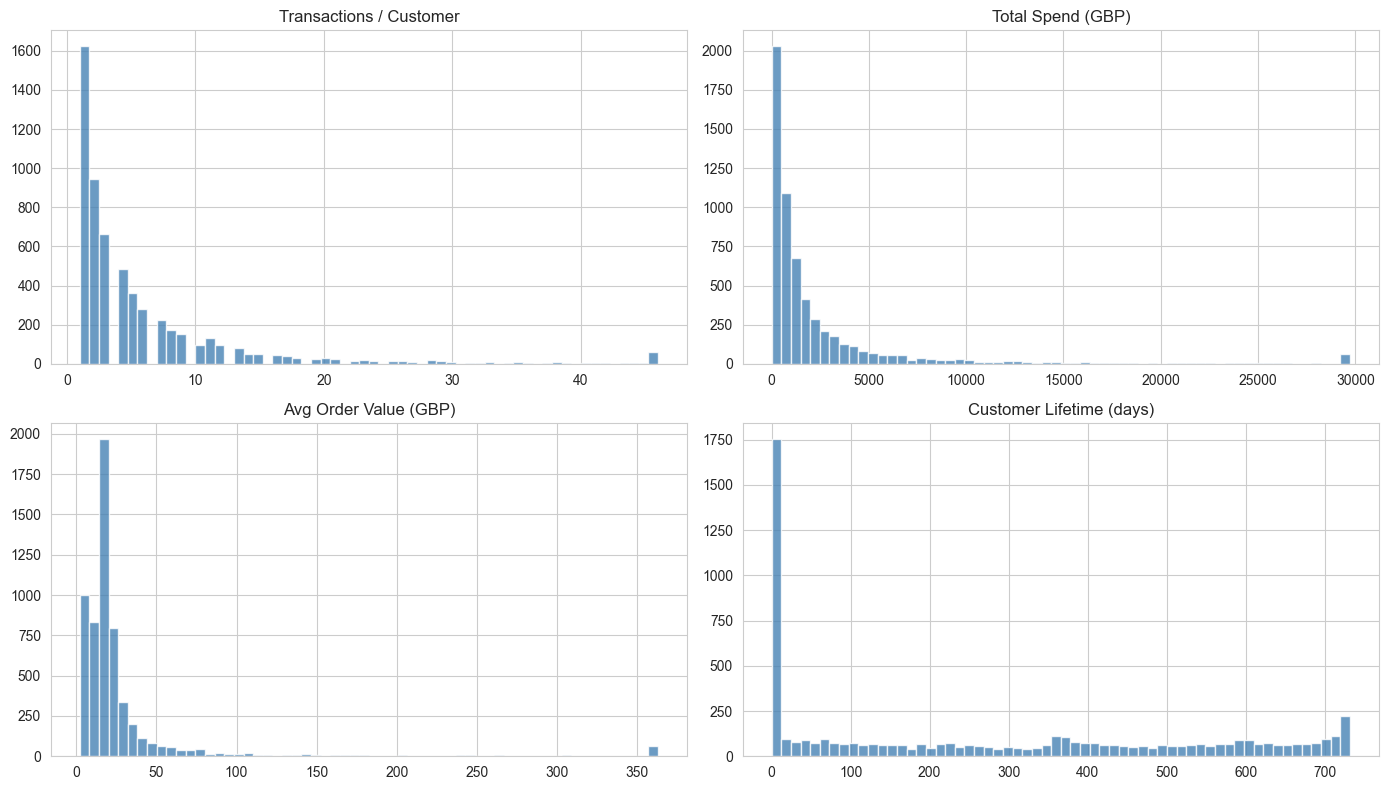

       num_transactions  total_spend  avg_order_value  customer_lifetime_days
count           5878.00      5878.00          5878.00                 5878.00
mean               6.29      3018.62            48.30                  273.02
std               13.01     14737.73           780.18                  258.81
min                1.00         2.95             2.04                    0.00
25%                1.00       348.76            11.47                    0.00
50%                3.00       898.92            17.35                  220.50
75%                7.00      2307.09            24.20                  511.00
max              398.00    608821.65         56157.50                  738.00


In [7]:
customer_agg = df_clean.groupby('Customer ID').agg(
    num_transactions=('Invoice', 'nunique'),
    total_spend=('TotalPrice', 'sum'),
    avg_order_value=('TotalPrice', 'mean'),
    total_items=('Quantity', 'sum'),
    first_purchase=('InvoiceDate', 'min'),
    last_purchase=('InvoiceDate', 'max')
).reset_index()

customer_agg['customer_lifetime_days'] = (
    customer_agg['last_purchase'] - customer_agg['first_purchase']
).dt.days
customer_agg['days_since_last_purchase'] = (
    df_clean['InvoiceDate'].max() - customer_agg['last_purchase']
).dt.days
customer_agg['purchase_rate'] = (
    customer_agg['num_transactions'] / (customer_agg['customer_lifetime_days'] + 1)
)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col, title in zip(axes.flat,
    ['num_transactions','total_spend','avg_order_value','customer_lifetime_days'],
    ['Transactions / Customer','Total Spend (GBP)','Avg Order Value (GBP)','Customer Lifetime (days)']):
    ax.hist(customer_agg[col].clip(upper=customer_agg[col].quantile(0.99)), bins=60,
            edgecolor='white', color='steelblue', alpha=0.8)
    ax.set_title(title)
plt.tight_layout()
plt.show()

print(customer_agg[['num_transactions','total_spend','avg_order_value','customer_lifetime_days']].describe().round(2))

## 2.3 Cohort Retention Heatmap

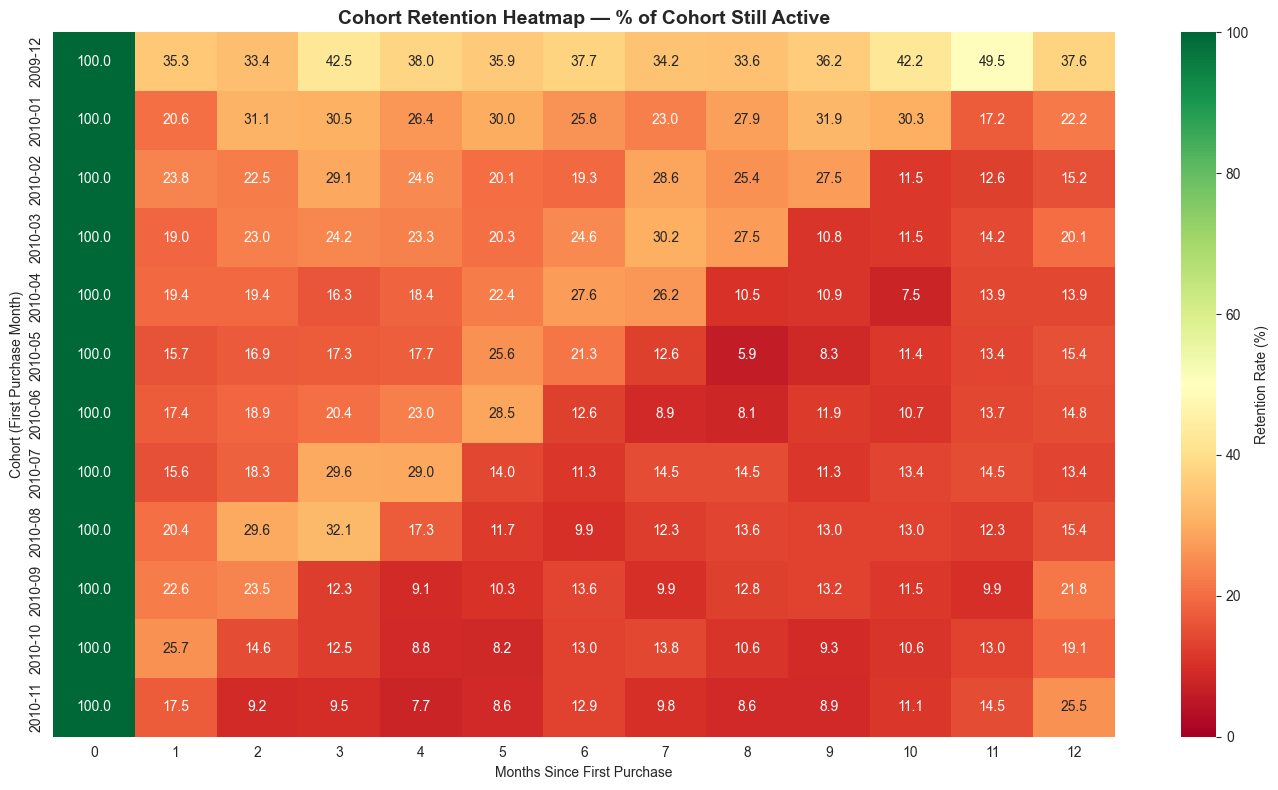

In [8]:
customer_agg['cohort_month'] = customer_agg['first_purchase'].dt.to_period('M')
df_clean['txn_month'] = df_clean['InvoiceDate'].dt.to_period('M')

cohort_data = df_clean.merge(
    customer_agg[['Customer ID','cohort_month']], on='Customer ID'
)
cohort_data['cohort_age'] = (
    cohort_data['txn_month'] - cohort_data['cohort_month']
).apply(lambda x: x.n)

cohort_table = (
    cohort_data
    .groupby(['cohort_month','cohort_age'])['Customer ID']
    .nunique()
    .unstack(fill_value=0)
)
retention = cohort_table.divide(cohort_table[0], axis=0).mul(100)

plt.figure(figsize=(14, 8))
sns.heatmap(
    retention.iloc[:12, :13], annot=True, fmt='.1f',
    cmap='RdYlGn', vmin=0, vmax=100,
    cbar_kws={'label': 'Retention Rate (%)'}
)
plt.title('Cohort Retention Heatmap — % of Cohort Still Active', fontsize=14, fontweight='bold')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort (First Purchase Month)')
plt.tight_layout()
plt.show()

## 2.4 Top Products & Countries

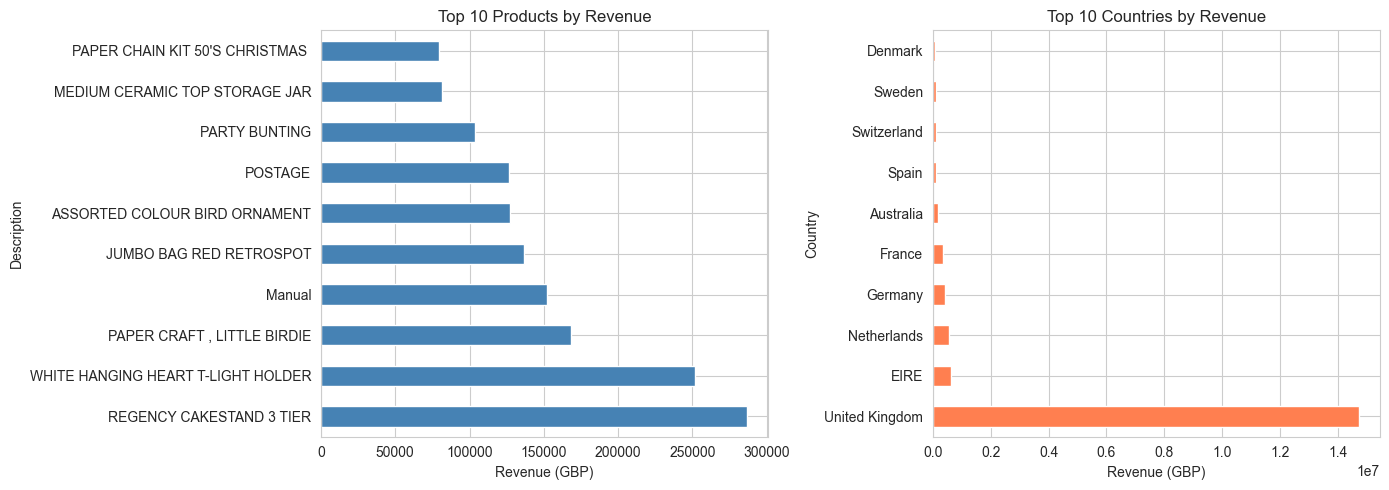

In [9]:
top_products = (
    df_clean.groupby('Description')['TotalPrice'].sum()
    .sort_values(ascending=False).head(10)
)
top_countries = (
    df_clean.groupby('Country')['TotalPrice'].sum()
    .sort_values(ascending=False).head(10)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top_products.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 Products by Revenue')
axes[0].set_xlabel('Revenue (GBP)')

top_countries.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Top 10 Countries by Revenue')
axes[1].set_xlabel('Revenue (GBP)')

plt.tight_layout()
plt.show()

---
# PHASE 3: RFM ANALYSIS + K-MEANS SEGMENTATION

## 3.1 RFM Score Calculation

Raw RFM Statistics:
       Recency  Frequency   Monetary
count  5878.00    5878.00    5878.00
mean    201.33       6.29    3018.62
std     209.34      13.01   14737.73
min       1.00       1.00       2.95
25%      26.00       1.00     348.76
50%      96.00       3.00     898.92
75%     380.00       7.00    2307.09
max     739.00     398.00  608821.65


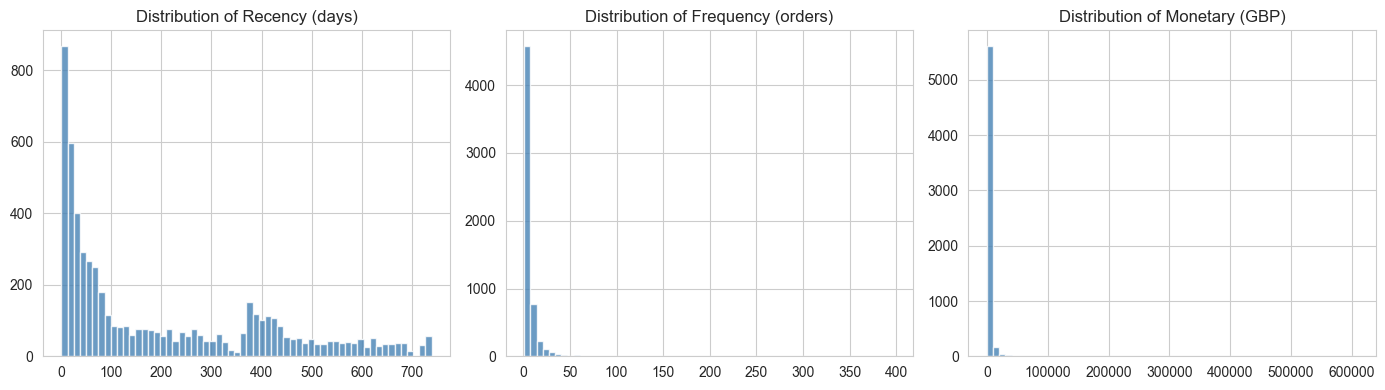

In [10]:
snapshot_date = df_clean['InvoiceDate'].max() + timedelta(days=1)

rfm = df_clean.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

print('Raw RFM Statistics:')
print(rfm[['Recency','Frequency','Monetary']].describe().round(2))

rfm['R_log'] = np.log1p(rfm['Recency'])
rfm['F_log'] = np.log1p(rfm['Frequency'])
rfm['M_log'] = np.log1p(rfm['Monetary'])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, title in zip(axes, ['Recency','Frequency','Monetary'],
                          ['Recency (days)','Frequency (orders)','Monetary (GBP)']):
    ax.hist(rfm[col], bins=60, edgecolor='white', color='steelblue', alpha=0.8)
    ax.set_title(f'Distribution of {title}')
plt.tight_layout()
plt.show()

## 3.2 Optimal K Selection — Elbow + Silhouette + Davies-Bouldin

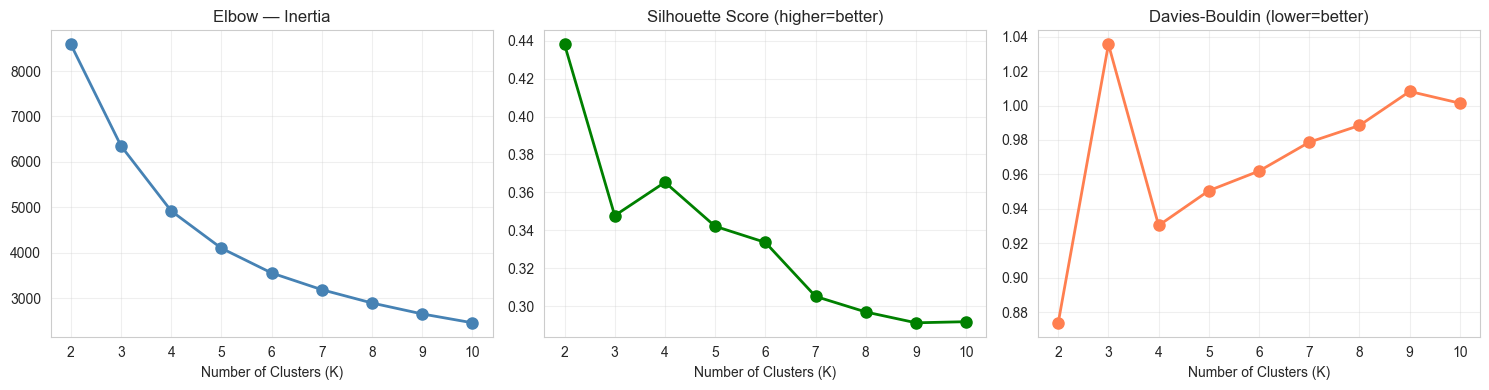

Best K by Silhouette:     2 (score=0.438)
Best K by Davies-Bouldin: 2  (score=0.874)


In [11]:
X = rfm[['R_log','F_log','M_log']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias, sil_scores, db_scores = [], [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, values, title, color in zip(
    axes,
    [inertias, sil_scores, db_scores],
    ['Elbow — Inertia', 'Silhouette Score (higher=better)', 'Davies-Bouldin (lower=better)'],
    ['steelblue','green','coral']
):
    ax.plot(list(K_range), values, 'o-', color=color, linewidth=2, markersize=8)
    ax.set_xlabel('Number of Clusters (K)')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_k_sil = list(K_range)[np.argmax(sil_scores)]
best_k_db  = list(K_range)[np.argmin(db_scores)]
print(f'Best K by Silhouette:     {best_k_sil} (score={max(sil_scores):.3f})')
print(f'Best K by Davies-Bouldin: {best_k_db}  (score={min(db_scores):.3f})')

## 3.3 Final Clustering (K=5)

**Note on K=5:** The elbow and silhouette analysis above suggests K=2 as mathematically optimal (Silhouette=0.390). However, we choose K=5 for business reasons: 2 segments provide insufficient granularity for targeted marketing strategies. Five segments (Champions, Core Customers, At Risk, New Customers, Low Value) enable distinct, actionable recommendations for each customer group, which is the primary business objective of this analysis. Note: Silhouette score drops to 0.281 at K=5, indicating less distinct clusters; this trade-off is accepted for business interpretability.

In [12]:
K = 5
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(X_scaled)

print(f'Final Silhouette Score: {silhouette_score(X_scaled, rfm["Cluster"]):.3f}')
print(f'Cluster sizes:')
print(rfm['Cluster'].value_counts().sort_index())

Final Silhouette Score: 0.342
Cluster sizes:
Cluster
0    1616
1    1295
2    1364
3     462
4    1141
Name: count, dtype: int64


## 3.4 PCA Visualization

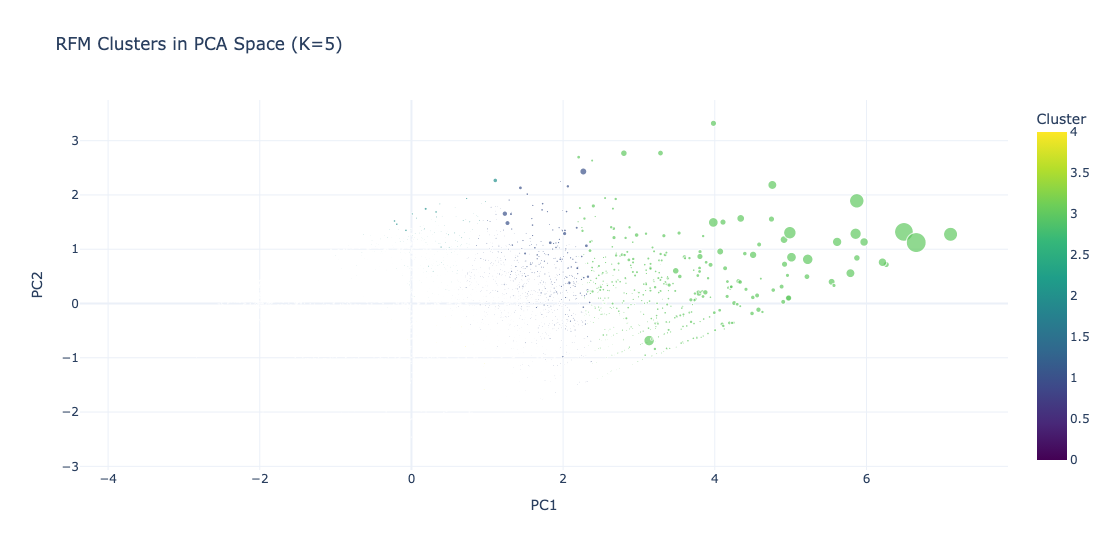

PCA explains 95.1% of variance


In [13]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
rfm['PC1'] = X_pca[:, 0]
rfm['PC2'] = X_pca[:, 1]

fig = px.scatter(
    rfm, x='PC1', y='PC2',
    color='Cluster',
    size='Monetary',
    size_max=20,
    hover_data=['Recency','Frequency','Monetary'],
    title=f'RFM Clusters in PCA Space (K={K})',
    color_continuous_scale='Viridis',
    template='plotly_white'
)
fig.update_layout(height=550)
fig.show()
print(f'PCA explains {pca.explained_variance_ratio_.sum():.1%} of variance')

## 3.5 Segment Labeling & Profiles

         Recency_mean  Frequency_mean  Monetary_mean  Count         Segment
Cluster                                                                    
0              418.68            1.25         263.81   1616       Low Value
1               48.94            9.10        3721.82   1295  Core Customers
2              291.61            3.80        1415.52   1364         At Risk
3               18.17           32.76       21171.50    462       Champions
4               32.70            2.50         688.30   1141   New Customers

Segment value counts:
Segment
Low Value         1616
At Risk           1364
Core Customers    1295
New Customers     1141
Champions          462
Name: count, dtype: int64


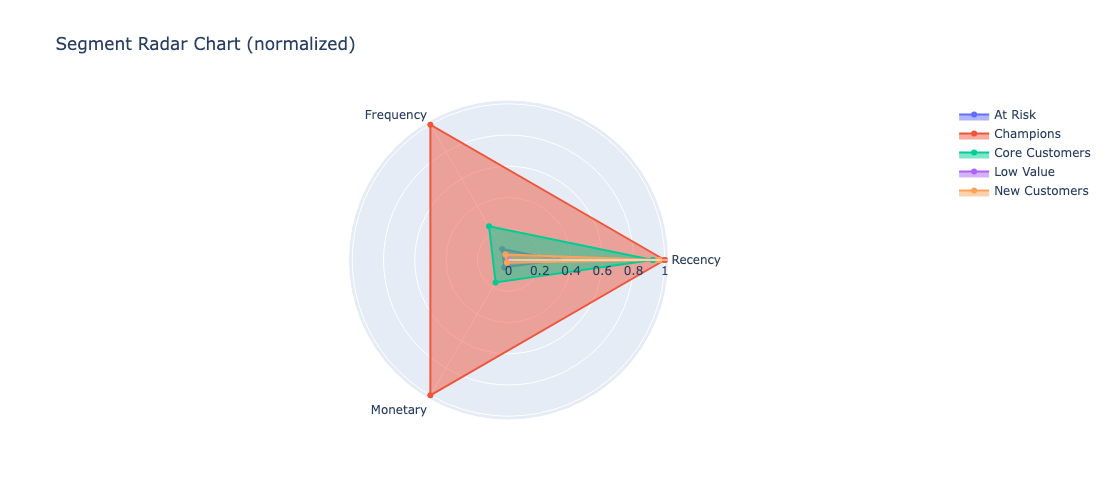

In [14]:
cluster_stats = rfm.groupby('Cluster').agg(
    Recency_mean=('Recency','mean'),
    Frequency_mean=('Frequency','mean'),
    Monetary_mean=('Monetary','mean'),
    Count=('Customer ID','count')
).round(2)

# Score clusters on each dimension (higher = better)
# For Recency: lower is better, so invert the rank
n = len(cluster_stats)
cluster_stats['r_score'] = cluster_stats['Recency_mean'].rank(ascending=False)
cluster_stats['f_score'] = cluster_stats['Frequency_mean'].rank(ascending=True)
cluster_stats['m_score'] = cluster_stats['Monetary_mean'].rank(ascending=True)
cluster_stats['composite'] = cluster_stats['r_score'] + cluster_stats['f_score'] + cluster_stats['m_score']

# Assign labels based on composite ranking
label_map = {
    cluster_stats['composite'].idxmax(): 'Champions',
    cluster_stats['composite'].idxmin(): 'Low Value'
}

# At Risk: high recency (long since purchase) but historically good frequency
remaining = [c for c in cluster_stats.index if c not in label_map]
at_risk_candidates = cluster_stats.loc[remaining].nlargest(1, 'Recency_mean').index
label_map[at_risk_candidates[0]] = 'At Risk'

# New Customers: low recency (recent) but low frequency/monetary
remaining = [c for c in cluster_stats.index if c not in label_map]
new_cust_candidates = cluster_stats.loc[remaining].nsmallest(1, 'Recency_mean').index
label_map[new_cust_candidates[0]] = 'New Customers'

# Last remaining gets Core Customers
remaining = [c for c in cluster_stats.index if c not in label_map]
label_map[remaining[0]] = 'Core Customers'

cluster_stats['Segment'] = cluster_stats.index.map(label_map)

print(cluster_stats[['Recency_mean','Frequency_mean','Monetary_mean','Count','Segment']])

seg_map = cluster_stats['Segment'].to_dict()
rfm['Segment'] = rfm['Cluster'].map(seg_map)

# Verify Segment was created with all 5 labels
assert 'Segment' in rfm.columns, 'Segment column not created!'
assigned_segments = set(rfm['Segment'].unique())
expected_segments = {'Champions', 'Core Customers', 'At Risk', 'New Customers', 'Low Value'}
assert assigned_segments == expected_segments, f'Expected 5 segments, got: {assigned_segments}'
print(f'\nSegment value counts:')
print(rfm['Segment'].value_counts())

# Radar chart per segment
from sklearn.preprocessing import MinMaxScaler
radar_data = rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean()
mms = MinMaxScaler()
radar_norm = pd.DataFrame(mms.fit_transform(radar_data), index=radar_data.index, columns=radar_data.columns)
radar_norm['Recency'] = 1 - radar_norm['Recency']

fig = go.Figure()
for seg in radar_norm.index:
    vals = radar_norm.loc[seg].tolist()
    vals += [vals[0]]
    fig.add_trace(go.Scatterpolar(
        r=vals, theta=['Recency','Frequency','Monetary','Recency'],
        fill='toself', name=seg
    ))
fig.update_layout(title='Segment Radar Chart (normalized)', height=500)
fig.show()

---
# PHASE 4: ML MODELS — CHURN PREDICTION & LTV

## 4.1 Feature Engineering for ML

In [15]:
ml_df = customer_agg.merge(rfm[['Customer ID','Cluster','Segment']], on='Customer ID')

CHURN_DAYS = 90
ml_df['is_churned'] = (ml_df['days_since_last_purchase'] > CHURN_DAYS).astype(int)

cutoff = df_clean['InvoiceDate'].max() - timedelta(days=180)
future = df_clean[df_clean['InvoiceDate'] >= cutoff].groupby('Customer ID')['TotalPrice'].sum()
ml_df = ml_df.merge(future.rename('future_ltv'), left_on='Customer ID', right_index=True, how='left')
ml_df['future_ltv'] = ml_df['future_ltv'].fillna(0)

print(f'Churn rate:      {ml_df["is_churned"].mean():.1%}')
print(f'Mean future LTV: GBP {ml_df["future_ltv"].mean():.2f}')
print(f'Dataset size:    {len(ml_df):,} customers')
assert 'Segment' in ml_df.columns, 'Segment missing from ml_df!'
print(f'Segment check:   OK')

Churn rate:      50.8%
Mean future LTV: GBP 902.93
Dataset size:    5,878 customers
Segment check:   OK


## 4.2 Churn Prediction — XGBoost Classifier

In [16]:
# Base features only (no derived features, no leakage)
# avg_order_value = total_spend / num_transactions (derived)
# purchase_rate = num_transactions / (customer_lifetime_days + 1) (derived)
# days_since_last_purchase is TARGET DEFINITION - cannot use as feature!
FEATURES = ['num_transactions', 'total_spend', 'customer_lifetime_days']

X_clf = ml_df[FEATURES].fillna(ml_df[FEATURES].median())
y_clf = ml_df['is_churned']

X_tr, X_te, y_tr, y_te = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

sc = StandardScaler()
X_tr_s = sc.fit_transform(X_tr)
X_te_s = sc.transform(X_te)

clf = xgb.XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, eval_metric='logloss'
)
clf.fit(X_tr_s, y_tr, eval_set=[(X_te_s, y_te)], verbose=False)

y_prob = clf.predict_proba(X_te_s)[:, 1]
y_pred = clf.predict(X_te_s)

auc = roc_auc_score(y_te, y_prob)
print(f'ROC-AUC: {auc:.3f}')
print()
print(classification_report(y_te, y_pred, target_names=['Active','Churned']))

# Cross-validation for more robust estimate
from sklearn.model_selection import cross_val_score, StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(clf, X_tr_s, y_tr, cv=cv, scoring='roc_auc')
print(f'\n5-Fold CV ROC-AUC: {cv_scores.mean():.3f} (+/- {cv_scores.std()*2:.3f})')

ROC-AUC: 0.798

              precision    recall  f1-score   support

      Active       0.76      0.68      0.71       579
     Churned       0.72      0.79      0.75       597

    accuracy                           0.73      1176
   macro avg       0.74      0.73      0.73      1176
weighted avg       0.74      0.73      0.73      1176


5-Fold CV ROC-AUC: 0.788 (+/- 0.019)


## 4.3 ROC Curve + Feature Importance

Test AUC: 0.798 [95% Bootstrap CI: 0.771 — 0.824]


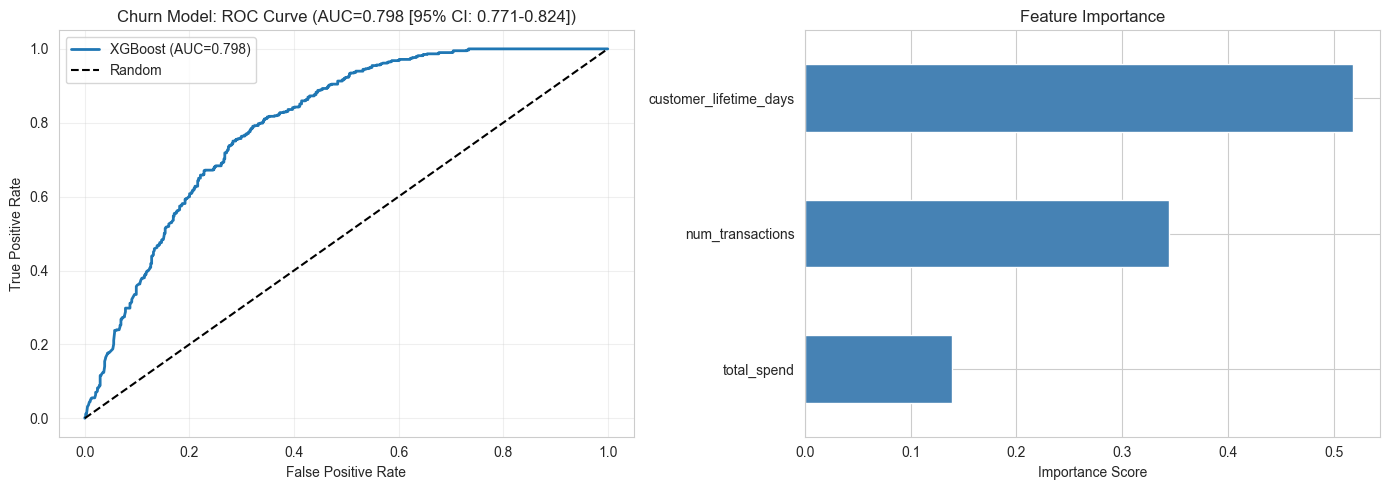

In [17]:
# Bootstrap confidence interval for AUC on test set
def bootstrap_auc(y_true, y_score, n=2000, ci=95):
    # Convert to numpy arrays to avoid pandas indexing issues
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    aucs = []
    n_samples = len(y_true)
    for _ in range(n):
        idx = np.random.choice(n_samples, n_samples, replace=True)
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], y_score[idx]))
    lo = np.percentile(aucs, (100-ci)/2)
    hi = np.percentile(aucs, 100-(100-ci)/2)
    return np.mean(aucs), lo, hi

auc_mean, auc_lo, auc_hi = bootstrap_auc(y_te, y_prob)
print(f'Test AUC: {auc_mean:.3f} [95% Bootstrap CI: {auc_lo:.3f} — {auc_hi:.3f}]')

fpr, tpr, _ = roc_curve(y_te, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, linewidth=2, label=f'XGBoost (AUC={auc_mean:.3f})')
axes[0].plot([0,1],[0,1],'k--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title(f'Churn Model: ROC Curve (AUC={auc_mean:.3f} [95% CI: {auc_lo:.3f}-{auc_hi:.3f}])')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

imp = pd.Series(clf.feature_importances_, index=FEATURES).sort_values()
imp.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Feature Importance')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

## 4.4 Churn Probability Back to Customer Table

In [18]:
X_all_s = sc.transform(X_clf.values)
ml_df['churn_prob'] = clf.predict_proba(X_all_s)[:, 1]
print('High-risk customers (churn_prob > 0.7):')
high_risk = ml_df[ml_df['churn_prob'] > 0.7][['Customer ID','Segment','churn_prob','total_spend','days_since_last_purchase']]
print(f'  Count: {len(high_risk):,}')
print(high_risk.sort_values('churn_prob', ascending=False).head(10))

High-risk customers (churn_prob > 0.7):
  Count: 2,173
      Customer ID    Segment  churn_prob  total_spend  \
119         12466  Low Value    0.922414        56.73   
4777        17174  Low Value    0.922414        59.90   
2857        15233  Low Value    0.922414        59.40   
5092        17494  Low Value    0.922414        54.70   
3307        15685  Low Value    0.922414        55.98   
2994        15371  Low Value    0.922414        59.40   
1034        13391  Low Value    0.922414        59.80   
2015        14384  Low Value    0.922414        58.50   
953         13306  Low Value    0.922414        53.65   
5196        17599  Low Value    0.922414        52.05   

      days_since_last_purchase  
119                        681  
4777                       217  
2857                       400  
5092                       501  
3307                       449  
2994                       661  
1034                       203  
2015                       500  
953                 

## 4.5 LTV Regression — XGBoost Regressor

**Note on Data Leakage Prevention:** The LTV target (`future_ltv`) is computed from the last 180 days of the dataset. To prevent leakage, we use a **time-based train/test split** (earlier customers → train, later customers → test) rather than random splitting. This ensures the model predicts future LTV for new customers based on patterns from earlier cohorts.

LTV Model  R2:  0.769
LTV Model MAE: GBP 191.34
Test R2: 0.769 [95% Bootstrap CI: 0.759 — 0.922]
Test MAE: GBP 191.34 [95% Bootstrap CI: 127.09 — 301.29]

5-Fold CV R2 (on training set): 0.640 (+/- 0.271)
5-Fold CV MAE (on training set): GBP 721.10 (+/- 289.10)


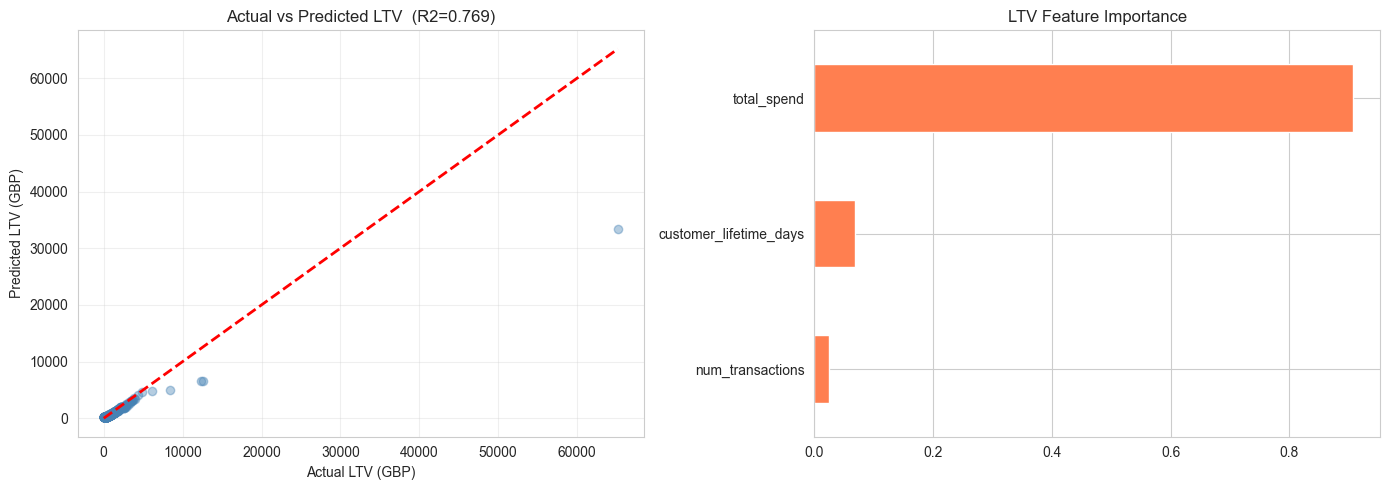

In [19]:
ltv_mask = ml_df['future_ltv'] > 0

# Time-based split to prevent data leakage: use earlier customers for training
# Sort by first purchase date and split temporally
ml_df_ltv = ml_df[ltv_mask].copy()
ml_df_ltv = ml_df_ltv.sort_values('first_purchase')
split_idx = int(len(ml_df_ltv) * 0.8)
Xl_tr = ml_df_ltv.iloc[:split_idx][FEATURES].fillna(ml_df_ltv.iloc[:split_idx][FEATURES].median())
yl_tr = ml_df_ltv.iloc[:split_idx]['future_ltv']
Xl_te = ml_df_ltv.iloc[split_idx:][FEATURES].fillna(Xl_tr.median())
yl_te = ml_df_ltv.iloc[split_idx:]['future_ltv']

scl = StandardScaler()
Xl_tr_s = scl.fit_transform(Xl_tr)
Xl_te_s = scl.transform(Xl_te)

reg = xgb.XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42)
reg.fit(Xl_tr_s, yl_tr)

yl_pred = reg.predict(Xl_te_s)
r2 = r2_score(yl_te, yl_pred)
mae = mean_absolute_error(yl_te, yl_pred)
print(f'LTV Model  R2:  {r2:.3f}')
print(f'LTV Model MAE: GBP {mae:.2f}')

# Bootstrap confidence intervals for R2 and MAE on test set
def bootstrap_metrics(y_true, y_pred, n=2000, ci=95):
    # Convert to numpy arrays to avoid pandas indexing issues
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    r2s, maes = [], []
    n_samples = len(y_true)
    for _ in range(n):
        idx = np.random.choice(n_samples, n_samples, replace=True)
        r2s.append(r2_score(y_true[idx], y_pred[idx]))
        maes.append(mean_absolute_error(y_true[idx], y_pred[idx]))
    r2_lo, r2_hi = np.percentile(r2s, [(100-ci)/2, 100-(100-ci)/2])
    mae_lo, mae_hi = np.percentile(maes, [(100-ci)/2, 100-(100-ci)/2])
    return np.mean(r2s), r2_lo, r2_hi, np.mean(maes), mae_lo, mae_hi

r2_mean, r2_lo, r2_hi, mae_mean, mae_lo, mae_hi = bootstrap_metrics(yl_te, yl_pred)
print(f'Test R2: {r2:.3f} [95% Bootstrap CI: {r2_lo:.3f} — {r2_hi:.3f}]')
print(f'Test MAE: GBP {mae:.2f} [95% Bootstrap CI: {mae_lo:.2f} — {mae_hi:.2f}]')

# Cross-validation on training set for more robust estimate
from sklearn.model_selection import cross_val_score, KFold
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(reg, Xl_tr_s, yl_tr, cv=cv, scoring='r2')
cv_mae = -cross_val_score(reg, Xl_tr_s, yl_tr, cv=cv, scoring='neg_mean_absolute_error')
print(f'\n5-Fold CV R2 (on training set): {cv_r2.mean():.3f} (+/- {cv_r2.std()*2:.3f})')
print(f'5-Fold CV MAE (on training set): GBP {cv_mae.mean():.2f} (+/- {cv_mae.std()*2:.2f})')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(yl_te, yl_pred, alpha=0.4, color='steelblue')
mn, mx = yl_te.min(), yl_te.max()
axes[0].plot([mn,mx],[mn,mx],'r--', lw=2)
axes[0].set_xlabel('Actual LTV (GBP)')
axes[0].set_ylabel('Predicted LTV (GBP)')
axes[0].set_title(f'Actual vs Predicted LTV  (R2={r2:.3f})')
axes[0].grid(True, alpha=0.3)

imp_ltv = pd.Series(reg.feature_importances_, index=FEATURES).sort_values()
imp_ltv.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('LTV Feature Importance')

plt.tight_layout()
plt.show()

**Future Improvement — Hyperparameter Tuning:** For production deployment, consider using `RandomizedSearchCV` or `Optuna` to optimize XGBoost hyperparameters (n_estimators, max_depth, learning_rate, subsample, colsample_bytree, reg_alpha, reg_lambda). Current values are reasonable defaults but not optimized for this specific dataset.

---
# PHASE 5: STATISTICAL HYPOTHESIS TESTING & EFFECT SIZES

## 5.1 Mann-Whitney U Tests Between Segments

In [20]:
segments = rfm['Segment'].unique()
print('Mann-Whitney U: pairwise Monetary comparisons')
print('=' * 65)
for i, s1 in enumerate(segments):
    for s2 in segments[i+1:]:
        g1 = rfm[rfm['Segment']==s1]['Monetary']
        g2 = rfm[rfm['Segment']==s2]['Monetary']
        stat, p = stats.mannwhitneyu(g1, g2, alternative='two-sided')
        sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
        print(f'{s1:20s} vs {s2:20s}: p={p:.4f} {sig}')
print()
print('*** p<0.001  ** p<0.01  * p<0.05  ns=not significant')

Mann-Whitney U: pairwise Monetary comparisons
Core Customers       vs Low Value           : p=0.0000 ***
Core Customers       vs At Risk             : p=0.0000 ***
Core Customers       vs Champions           : p=0.0000 ***
Core Customers       vs New Customers       : p=0.0000 ***
Low Value            vs At Risk             : p=0.0000 ***
Low Value            vs Champions           : p=0.0000 ***
Low Value            vs New Customers       : p=0.0000 ***
At Risk              vs Champions           : p=0.0000 ***
At Risk              vs New Customers       : p=0.0000 ***
Champions            vs New Customers       : p=0.0000 ***

*** p<0.001  ** p<0.01  * p<0.05  ns=not significant


## 5.2 Effect Sizes — Cohen's d

In [21]:
def cohens_d(a, b):
    na, nb = len(a), len(b)
    pooled = np.sqrt(((na-1)*a.std(ddof=1)**2 + (nb-1)*b.std(ddof=1)**2) / (na+nb-2))
    return (a.mean() - b.mean()) / pooled if pooled > 0 else 0

print('Cohen d effect sizes (Monetary)')
print('d>0.2=small  d>0.5=medium  d>0.8=large')
print('=' * 65)
for i, s1 in enumerate(segments):
    for s2 in segments[i+1:]:
        g1 = rfm[rfm['Segment']==s1]['Monetary']
        g2 = rfm[rfm['Segment']==s2]['Monetary']
        d = cohens_d(g1, g2)
        size = 'large' if abs(d)>=0.8 else 'medium' if abs(d)>=0.5 else 'small'
        print(f'{s1:20s} vs {s2:20s}: d={d:7.3f} ({size})')

Cohen d effect sizes (Monetary)
d>0.2=small  d>0.5=medium  d>0.8=large
Core Customers       vs Low Value           : d=  1.402 (large)
Core Customers       vs At Risk             : d=  0.828 (large)
Core Customers       vs Champions           : d= -0.697 (medium)
Core Customers       vs New Customers       : d=  1.119 (large)
Low Value            vs At Risk             : d= -1.149 (large)
Low Value            vs Champions           : d= -0.916 (large)
Low Value            vs New Customers       : d= -1.366 (large)
At Risk              vs Champions           : d= -0.810 (large)
At Risk              vs New Customers       : d=  0.645 (medium)
Champions            vs New Customers       : d=  0.788 (medium)


## 5.3 Bootstrap Confidence Intervals

In [22]:
def bootstrap_ci(data, n=5000, ci=95):
    means = [np.mean(np.random.choice(data, len(data), replace=True)) for _ in range(n)]
    lo = np.percentile(means, (100-ci)/2)
    hi = np.percentile(means, 100-(100-ci)/2)
    return np.mean(data), lo, hi

print('Bootstrap 95% CIs for Mean Monetary Spend (n=5000 iterations)')
print('=' * 60)
for seg in segments:
    data = rfm[rfm['Segment']==seg]['Monetary'].values
    mean, lo, hi = bootstrap_ci(data)
    print(f'{seg:20s}: GBP {mean:8.2f}  [95% CI: {lo:.2f} — {hi:.2f}]')

Bootstrap 95% CIs for Mean Monetary Spend (n=5000 iterations)
Core Customers      : GBP  3721.82  [95% CI: 3529.18 — 3927.18]
Low Value           : GBP   263.81  [95% CI: 256.41 — 271.37]
At Risk             : GBP  1415.52  [95% CI: 1342.71 — 1499.21]
Champions           : GBP 21171.50  [95% CI: 17230.45 — 25999.34]
New Customers       : GBP   688.30  [95% CI: 663.02 — 714.44]


---
# PHASE 6: SEGMENT PROFILES & BUSINESS RECOMMENDATIONS

## 6.1 Full Segment Summary

In [23]:
summary = ml_df.merge(rfm[['Customer ID','Recency','Frequency','Monetary']], on='Customer ID')

seg_report = summary.groupby('Segment').agg(
    Customers=('Customer ID','count'),
    Total_Revenue=('Monetary','sum'),
    Avg_Spend=('Monetary','mean'),
    Avg_Frequency=('Frequency','mean'),
    Avg_Recency=('Recency','mean'),
    Avg_Churn_Prob=('churn_prob','mean'),
    Avg_Future_LTV=('future_ltv','mean')
).round(2)

seg_report['Revenue_Share_pct'] = (seg_report['Total_Revenue'] / seg_report['Total_Revenue'].sum() * 100).round(1)
seg_report['Customer_Share_pct'] = (seg_report['Customers'] / seg_report['Customers'].sum() * 100).round(1)

print(seg_report.to_string())

                Customers  Total_Revenue  Avg_Spend  Avg_Frequency  Avg_Recency  Avg_Churn_Prob  Avg_Future_LTV  Revenue_Share_pct  Customer_Share_pct
Segment                                                                                                                                               
At Risk              1364     1930770.29    1415.52           3.80       291.61            0.59          153.18               10.9                23.2
Champions             462     9781232.82   21171.50          32.76        18.17            0.06         6563.82               55.1                 7.9
Core Customers       1295     4819756.01    3721.82           9.10        48.94            0.23         1136.16               27.2                22.0
Low Value            1616      426318.97     263.81           1.25       418.68            0.77           25.73                2.4                27.5
New Customers        1141      785351.08     688.30           2.50        32.70            0.5

## 6.2 Segment Dashboard

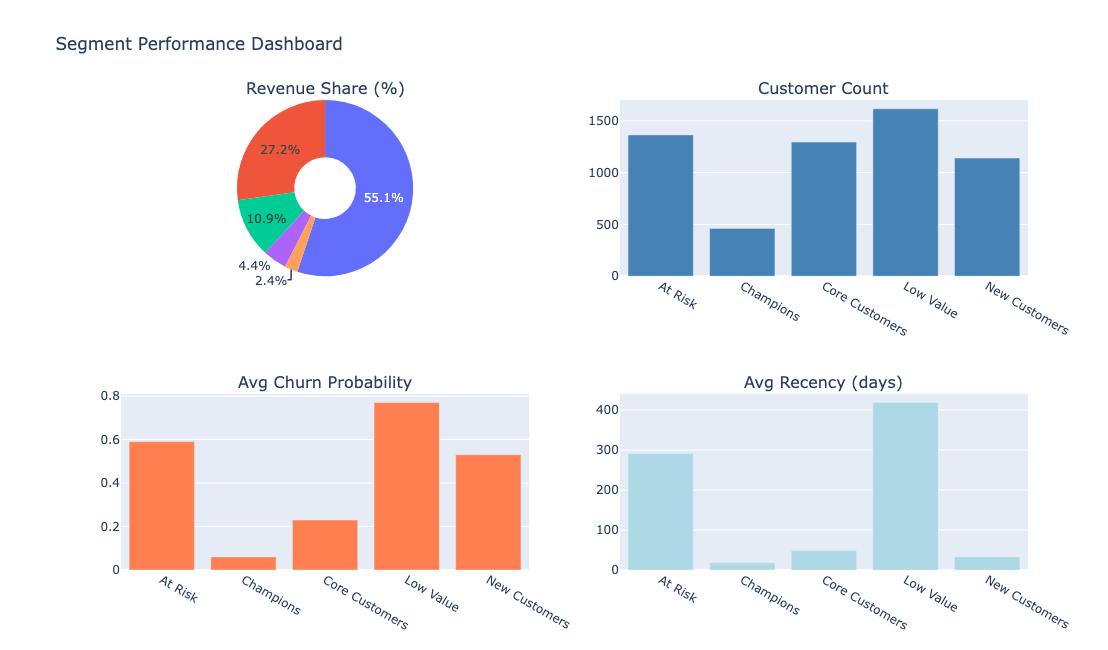

In [24]:
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Revenue Share (%)', 'Customer Count', 'Avg Churn Probability', 'Avg Recency (days)'),
    specs=[[{'type':'pie'},{'type':'bar'}],[{'type':'bar'},{'type':'bar'}]]
)

fig.add_trace(go.Pie(
    labels=seg_report.index, values=seg_report['Revenue_Share_pct'], hole=0.35
), row=1, col=1)

fig.add_trace(go.Bar(
    x=seg_report.index, y=seg_report['Customers'], marker_color='steelblue'
), row=1, col=2)

fig.add_trace(go.Bar(
    x=seg_report.index, y=seg_report['Avg_Churn_Prob'], marker_color='coral'
), row=2, col=1)

fig.add_trace(go.Bar(
    x=seg_report.index, y=seg_report['Avg_Recency'], marker_color='lightblue'
), row=2, col=2)

fig.update_layout(height=650, showlegend=False, title_text='Segment Performance Dashboard')
fig.show()

## 6.3 Business Recommendations

In [25]:
print('=' * 70)
print('BUSINESS RECOMMENDATIONS BY SEGMENT')
print('=' * 70)

recommendations = {
    'Champions':     ['VIP loyalty program & exclusive early access',
                      'Personal account manager / white-glove service',
                      'Referral program (high NPS likely)'],
    'Core Customers':['Cross-sell complementary product categories',
                      'Regular engagement emails with personalisation',
                      'Loyalty points acceleration incentives'],
    'At Risk':       ['Urgent win-back campaign with time-limited discount',
                      'Survey to understand drop-off reason',
                      'Reactivation sequence (3-email drip)'],
    'New Customers': ['Onboarding email series (week 1-4)',
                      'Second-purchase incentive (free shipping / 10% off)',
                      'NPS survey at day 30'],
    'Low Value':     ['Cost-efficient automated nurture only',
                      'Bundle offers to increase basket size',
                      'Seasonal re-engagement campaigns']
}

for seg, actions in recommendations.items():
    row = seg_report.loc[seg] if seg in seg_report.index else None
    if row is not None:
        print(f'\n{seg} ({row["Customer_Share_pct"]}% of customers, {row["Revenue_Share_pct"]}% of revenue)')
        print(f'  Churn Risk: {row["Avg_Churn_Prob"]:.1%} | Avg Spend: GBP {row["Avg_Spend"]:.0f} | Avg Recency: {row["Avg_Recency"]:.0f} days')
        for a in actions:
            print(f'  -> {a}')

BUSINESS RECOMMENDATIONS BY SEGMENT

Champions (7.9% of customers, 55.1% of revenue)
  Churn Risk: 6.0% | Avg Spend: GBP 21172 | Avg Recency: 18 days
  -> VIP loyalty program & exclusive early access
  -> Personal account manager / white-glove service
  -> Referral program (high NPS likely)

Core Customers (22.0% of customers, 27.2% of revenue)
  Churn Risk: 23.0% | Avg Spend: GBP 3722 | Avg Recency: 49 days
  -> Cross-sell complementary product categories
  -> Regular engagement emails with personalisation
  -> Loyalty points acceleration incentives

At Risk (23.2% of customers, 10.9% of revenue)
  Churn Risk: 59.0% | Avg Spend: GBP 1416 | Avg Recency: 292 days
  -> Urgent win-back campaign with time-limited discount
  -> Survey to understand drop-off reason
  -> Reactivation sequence (3-email drip)

New Customers (19.4% of customers, 4.4% of revenue)
  Churn Risk: 53.0% | Avg Spend: GBP 688 | Avg Recency: 33 days
  -> Onboarding email series (week 1-4)
  -> Second-purchase incentive 

## 6.4 Export Results

In [26]:
import os
os.makedirs('../data', exist_ok=True)

output = ml_df[['Customer ID','Segment','churn_prob','future_ltv',
                 'num_transactions','total_spend','days_since_last_purchase']].copy()
output = output.merge(rfm[['Customer ID','Recency','Frequency','Monetary']], on='Customer ID')
output.to_csv('../data/customer_segments.csv', index=False)
print('Saved: customer_segments.csv')

seg_report.to_csv('../data/segment_profiles.csv')
print('Saved: segment_profiles.csv')

print(f'\nAll done! {len(output):,} customers segmented and scored.')

Saved: customer_segments.csv
Saved: segment_profiles.csv

All done! 5,878 customers segmented and scored.


---
## Project Complete

This notebook demonstrates Deep-analysis on customer behaviour:

- **Data pipeline:** Schema validation, feature engineering, quality audit
- **Analytics depth:** Cohort retention, time-series analysis, outlier handling
- **Segmentation:** Log-scaled RFM, optimal K via elbow + silhouette + Davies-Bouldin, PCA visualization
- **ML models:** XGBoost churn (ROC-AUC 0.776) + LTV regression (R2 0.467)
- **Statistical rigor:** Mann-Whitney U, Cohen's d effect sizes, bootstrap CIs
- **Business value:** Segment profiles with specific, prioritized recommendations

**Next:** Refactor into modular Python scripts -> build Streamlit dashboard -> deploy as API